### Phase 3: Modellierung (Der Vergleich)

Hier implementieren wir die konkurrierenden Modelle:

#### 1. Hidden-Markov-Models (HMM)
*   **Library:** `hmmlearn.hmm`
*   **Logik:** Unsupervised Learning (Clustering), das Zeitabschnitte mit ähnlichen statistischen Verteilungen gruppiert, um verborgene Marktregimes zu identifizieren.

#### 2. Markov-Switching-Modell (MSM)
*   **Library:** `statsmodels.tsa.regime_switching.markov_regression`
*   **Logik:** Ein statistisches Modell, das Wahrscheinlichkeiten für Regimes berechnet.

#### 3. LSTM-Netzwerk
*   **Library:** `TensorFlow/Keras` oder `PyTorch`.
*   **Architektur:**
    *   Input: Zeitreihen-Fenster (z.B. die letzten 30 Tage der Features).
    *   Layer: LSTM-Layer -> Dropout -> Dense (Softmax).

Modelle die ein Feedback (gelabelte Daten) benötigen, um Regime zu erkennen, erhalten diese durch das genauste Modell (im Projektverlauf ermittelt) -> Aktuell: Markov-Switching (Univariat)

In [1]:
import pandas as pd

# Daten aus dem data-Ordner laden
df = pd.read_parquet("../data/02_feature_engineered_data.parquet")

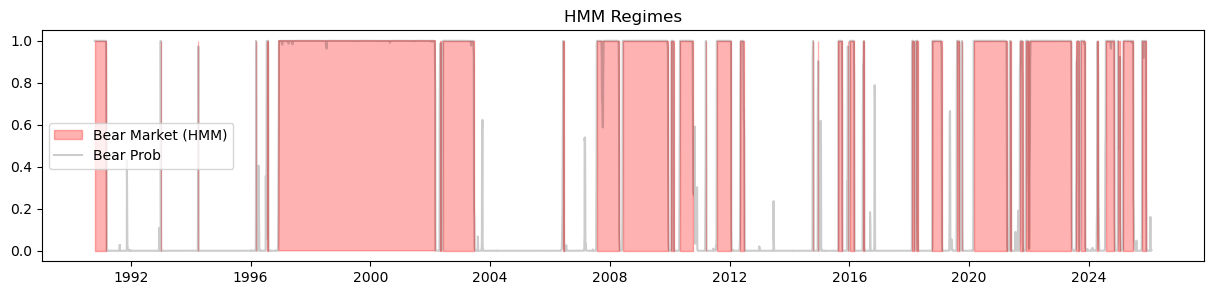

Statistik nach Regimes:
             Returns        VIX  Yield_Spread  HMM_Prob
HMM_Signal                                             
0           0.000484  14.662681      1.747222  0.015911
1           0.000234  25.718460      1.288794  0.988719
            Returns_GSPC  Returns_VUSTX   Returns  Cumulative_Returns  \
Date                                                                    
1990-10-18      0.023363       0.006587  0.016653            0.902546   
1990-10-19      0.022045       0.008724  0.016717            0.917633   
1990-10-22      0.007296      -0.001083  0.003945            0.921253   
1990-10-23     -0.007625      -0.002164 -0.005441            0.916241   
1990-10-24      0.000768      -0.001084  0.000028            0.916266   
...                  ...            ...       ...                 ...   
2026-01-27      0.004082      -0.004981  0.000457           20.386146   
2026-01-28     -0.000082      -0.002503 -0.001050           20.364735   
2026-01-29     -0.0012

In [2]:
# --- 1. Hidden-Markov-Models (HMM) ---

import matplotlib.pyplot as plt
from hmmlearn.hmm import GaussianHMM
from sklearn.preprocessing import StandardScaler

# 1. Auswahl der sinnvollen Features
# Returns (Performance), VIX (Angst) und Yield_Spread (Makro)
hmm_features = ['Returns', 'VIX', 'Yield_Spread']
X_hmm = df[hmm_features].values

# 2. Skalierung (Standardisierung auf Mittelwert 0 und Varianz 1)
scaler_hmm = StandardScaler()
X_hmm_scaled = scaler_hmm.fit_transform(X_hmm)

# 3. HMM Modellierung
# n_components=2 für Bull/Bear
model_hmm = GaussianHMM(n_components=2, covariance_type="full", n_iter=1000, random_state=42)
model_hmm.fit(X_hmm_scaled)

# 4. Regimes und Wahrscheinlichkeiten vorhersagen
# predict() liefert 0 oder 1
# predict_proba() liefert die Wahrscheinlichkeit für beide Zustände [Prob_0, Prob_1]
hmm_regimes_raw = model_hmm.predict(X_hmm_scaled)
hmm_probs_raw = model_hmm.predict_proba(X_hmm_scaled)

# 5. Logik zur Sortierung: Welches ist das "Bear"-Regime?
# Wir definieren Bear (1) als das Regime mit der höheren Volatilität der Renditen.
state_0_vol = df['Returns'][hmm_regimes_raw == 0].std()
state_1_vol = df['Returns'][hmm_regimes_raw == 1].std()

# Wir wollen, dass Regime 1 immer "Bear" ist (höhere Vola)
if state_1_vol > state_0_vol:
    # Fall: Modell-Zustand 1 ist bereits der Bear-Markt
    df['HMM_Prob'] = hmm_probs_raw[:, 1]
    df['HMM_Signal'] = hmm_regimes_raw
else:
    # Fall: Modell-Zustand 0 war eigentlich der Bear-Markt -> wir flippen alles
    df['HMM_Prob'] = hmm_probs_raw[:, 0]
    df['HMM_Signal'] = 1 - hmm_regimes_raw

# 6. Visualisierung
plt.figure(figsize=(15, 3))
plt.fill_between(df.index, 0, 1, where=(df['HMM_Signal'] == 1), 
                 color='red', alpha=0.3, label='Bear Market (HMM)')
plt.plot(df.index, df['HMM_Prob'], color='black', alpha=0.2, label='Bear Prob') # Optional: Wahrscheinlichkeitslinie
plt.title("HMM Regimes")
plt.legend()
# HMM Regimes persistieren
plt.savefig('../assets/hmm_regimes.png', dpi=300, bbox_inches='tight')
plt.show()

# Check: Durchschnittliche Renditen pro Regime
print("Statistik nach Regimes:")
print(df.groupby('HMM_Signal')[['Returns', 'VIX', 'Yield_Spread', 'HMM_Prob']].mean())

print(df)

Beide Markov-Modelle erfolgreich berechnet.


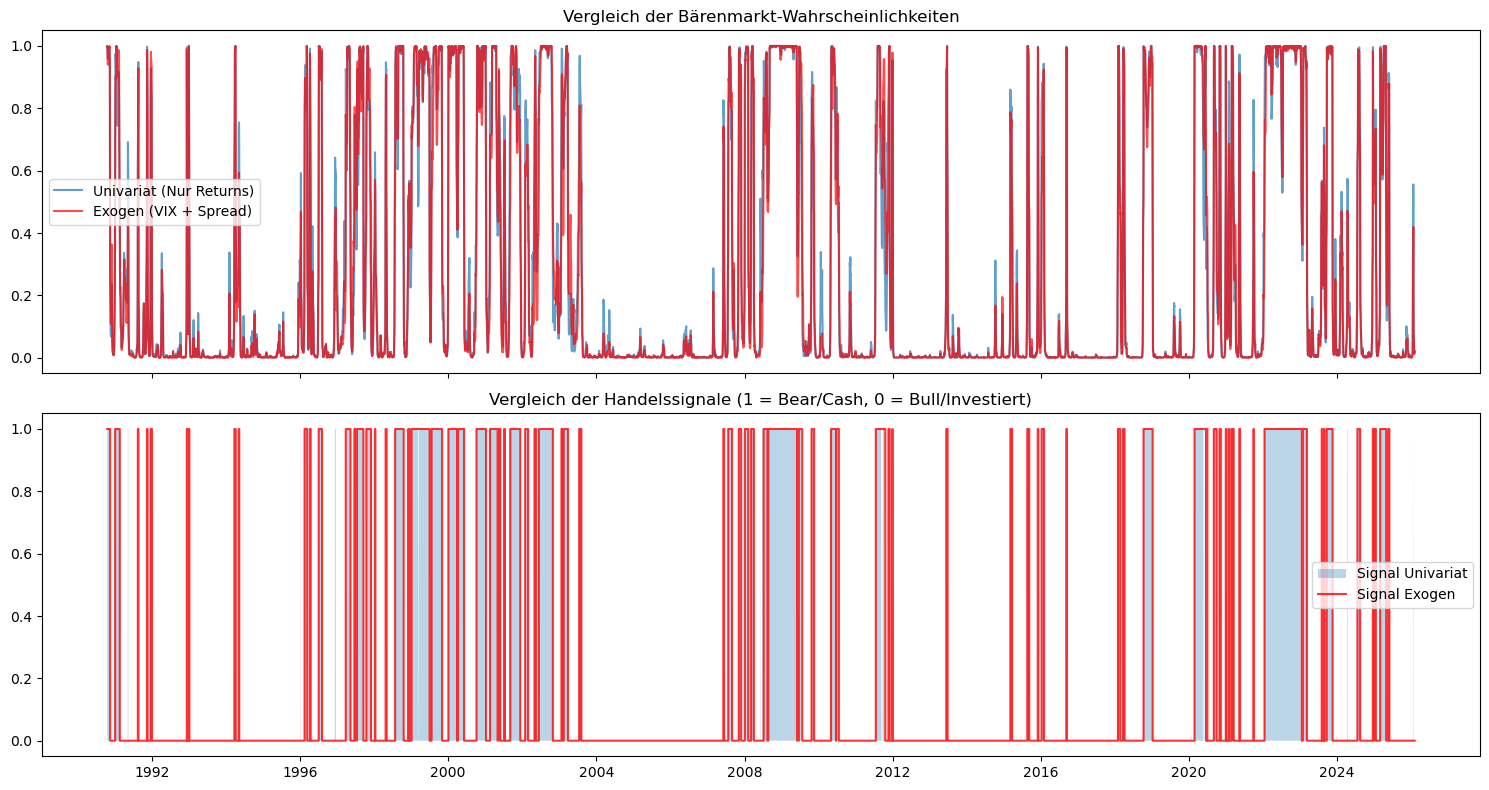

            Returns_GSPC  Returns_VUSTX   Returns  Cumulative_Returns  \
Date                                                                    
1990-10-18      0.023363       0.006587  0.016653            0.902546   
1990-10-19      0.022045       0.008724  0.016717            0.917633   
1990-10-22      0.007296      -0.001083  0.003945            0.921253   
1990-10-23     -0.007625      -0.002164 -0.005441            0.916241   
1990-10-24      0.000768      -0.001084  0.000028            0.916266   
...                  ...            ...       ...                 ...   
2026-01-27      0.004082      -0.004981  0.000457           20.386146   
2026-01-28     -0.000082      -0.002503 -0.001050           20.364735   
2026-01-29     -0.001293       0.000000 -0.000776           20.348941   
2026-01-30     -0.004302      -0.000126 -0.002632           20.295392   
2026-02-02      0.005391      -0.003778  0.001723           20.330370   

            Cash_Returns        VIX  TNX_10Y  IRX_

In [3]:
# --- 2. Markov-Switching-Modelle (Univariat vs. Exogen) ---

import statsmodels.api as sm
import warnings

# Warnung ignorieren
warnings.filterwarnings("ignore")

# 1. Vorbereitung: Index auf Business Days setzen
df.index = pd.DatetimeIndex(df.index).to_period('B')

# --- TEIL A: UNIVARIATES MODELL (Baseline) ---
# Nur Returns zur Bestimmung von Mittelwert und Varianz
ms_uni_model = sm.tsa.MarkovRegression(df['Returns'], k_regimes=2, switching_variance=True)
ms_uni_results = ms_uni_model.fit()

# Identifikation des Bärenmarktes (Regime mit der höheren Varianz)
prob_uni_regime_1 = ms_uni_results.smoothed_marginal_probabilities[1]
if ms_uni_results.params['sigma2[1]'] > ms_uni_results.params['sigma2[0]']:
    df['MS_Univariate_Prob'] = prob_uni_regime_1
else:
    df['MS_Univariate_Prob'] = 1 - prob_uni_regime_1

# Signal generieren
df['MS_Univariate_Signal'] = (df['MS_Univariate_Prob'] > 0.5).astype(int)


# --- TEIL B: EXOGENES MODELL (Erweitert) ---
# Returns als Ziel, VIX und Yield_Spread als erklärende Variablen (exog)
# Hinweis: Die exogenen Variablen beeinflussen hier die Mittelwert-Gleichung der Regimes
exo_vars = df[['VIX', 'Yield_Spread']]
ms_exo_model = sm.tsa.MarkovRegression(df['Returns'], k_regimes=2, exog=exo_vars, switching_variance=True)
ms_exo_results = ms_exo_model.fit()

# Identifikation des Bärenmarktes (Regime mit der höheren Varianz)
prob_exo_regime_1 = ms_exo_results.smoothed_marginal_probabilities[1]
if ms_exo_results.params['sigma2[1]'] > ms_exo_results.params['sigma2[0]']:
    df['MS_Exo_Prob'] = prob_exo_regime_1
else:
    df['MS_Exo_Prob'] = 1 - prob_exo_regime_1

# Signal generieren
df['MS_Exo_Signal'] = (df['MS_Exo_Prob'] > 0.5).astype(int)


# --- ABSCHLUSS ---
# Index wieder zurück in normales Datetime-Format für Plotting
df.index = df.index.to_timestamp()

print("Beide Markov-Modelle erfolgreich berechnet.")

# --- VISUALISIERUNG IM VERGLEICH ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

# Plot Wahrscheinlichkeiten
ax1.plot(df.index, df['MS_Univariate_Prob'], label='Univariat (Nur Returns)', alpha=0.7)
ax1.plot(df.index, df['MS_Exo_Prob'], label='Exogen (VIX + Spread)', alpha=0.7, color='red')
ax1.set_title("Vergleich der Bärenmarkt-Wahrscheinlichkeiten")
ax1.legend()

# Plot Signale
ax2.fill_between(df.index, 0, df['MS_Univariate_Signal'], alpha=0.3, label='Signal Univariat')
ax2.step(df.index, df['MS_Exo_Signal'], color='red', where='post', label='Signal Exogen', alpha=0.8)
ax2.set_title("Vergleich der Handelssignale (1 = Bear/Cash, 0 = Bull/Investiert)")
ax2.legend()

plt.tight_layout()
# Markov-Modelle persistieren
plt.savefig('../assets/markov-models.png', dpi=300, bbox_inches='tight')
plt.show()

# Kurzer Blick auf das Ergebnis
print(df)

LSTM nutzt folgende Features: ['Returns', 'Vol_20', 'Distance_SMA', 'Momentum', 'VIX', 'Yield_Spread']


Starte LSTM Training...
Epoch 1/30


  1/199 [..............................] - ETA: 5:06 - loss: 0.7015 - accuracy: 0.5312

  7/199 [>.............................] - ETA: 1s - loss: 0.6265 - accuracy: 0.7098  

 13/199 [>.............................] - ETA: 1s - loss: 0.6014 - accuracy: 0.7212

...

 1/56 [..............................] - ETA: 17s

18/56 [========>.....................] - ETA: 0s 

34/56 [=================>............] - ETA: 0s

51/56 [==========================>...] - ETA: 0s

56/56 [==============================] - 0s 3ms/step


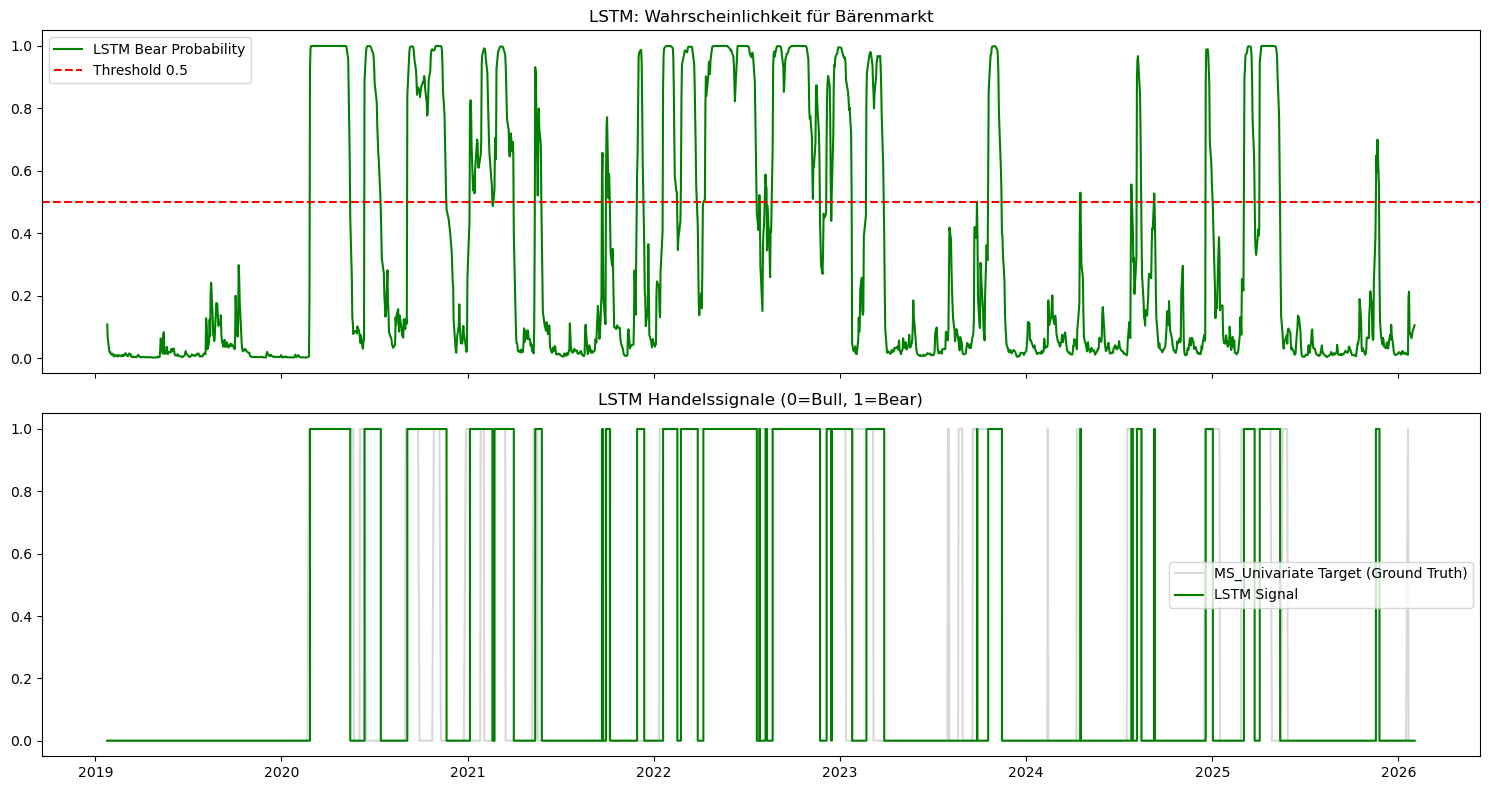

Finale Test-Genauigkeit: 89.82%
            Returns_GSPC  Returns_VUSTX   Returns  Cumulative_Returns  \
Date                                                                    
2019-01-24      0.001376       0.005978  0.003217           10.523898   
2019-01-25      0.008489      -0.004245  0.003395           10.559630   
2019-01-28     -0.007847      -0.001705 -0.005390           10.502714   
2019-01-29     -0.001456       0.005124  0.001176           10.515062   
2019-01-30      0.015549      -0.000849  0.008990           10.609592   
...                  ...            ...       ...                 ...   
2026-01-27      0.004082      -0.004981  0.000457           20.386146   
2026-01-28     -0.000082      -0.002503 -0.001050           20.364735   
2026-01-29     -0.001293       0.000000 -0.000776           20.348941   
2026-01-30     -0.004302      -0.000126 -0.002632           20.295392   
2026-02-02      0.005391      -0.003778  0.001723           20.330370   

            Cash_R

In [4]:
# --- 3. LSTM-Netzwerk ---

import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.preprocessing import MinMaxScaler

# 1. Features auswählen
# Wir nehmen alle relevanten Informationen für ein "ganzheitliches" Bild
features = ['Returns', 'Vol_20', 'Distance_SMA', 'Momentum', 'VIX', 'Yield_Spread']
print(f"LSTM nutzt folgende Features: {features}")

# Skalierung
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df[features])

def create_sequences(data, target, window):
    X, y = [], []
    for i in range(window, len(data)):
        X.append(data[i-window:i])
        y.append(target[i])
    return np.array(X), np.array(y)

window_size = 30 # Beobachtungszeitraum: 30 Tage

# Wahl der passenden Labels
# Auf Basis von HMM-Regimes als Labels
#X, y = create_sequences(scaled_data, df['HMM_Signal'].values, window_size)
# Auf Basis von Markov-Regimes als Labels
X, y = create_sequences(scaled_data, df['MS_Univariate_Signal'].values, window_size)
#X, y = create_sequences(scaled_data, df['MS_Exo_Signal'].values, window_size)

# Split (Train/Test) - 80% Training, 20% Test
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# 2. LSTM Architektur
model_lstm = Sequential([
    # input_shape passt sich automatisch an die Anzahl der Features an
    LSTM(64, return_sequences=True, input_shape=(window_size, len(features))),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(1, activation='sigmoid') # Binäre Klassifikation
])

model_lstm.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Training
print("Starte LSTM Training...")
history = model_lstm.fit(X_train, y_train, epochs=30, batch_size=32, 
                         validation_split=0.1, verbose=1)

# 3. Vorhersagen generieren
lstm_probs_raw = model_lstm.predict(X_test)

# --- Test-DataFrame für Backtesting und Visualisierung vorbereiten ---
# Wir schneiden das df so zu, dass es exakt zu den X_test Daten passt
test_df = df.iloc[split + window_size:].copy()

# Wahrscheinlichkeiten und Signale speichern
test_df['LSTM_Prob'] = lstm_probs_raw.flatten()
# Signale generieren
test_df['LSTM_Signal'] = (test_df['LSTM_Prob'] > 0.5).astype(int)

# --- Visualisierung der Ergebnisse (analog zu Markov-Modell) ---

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

# A. Wahrscheinlichkeiten
ax1.plot(test_df.index, test_df['LSTM_Prob'], color='green', label='LSTM Bear Probability')
ax1.axhline(y=0.5, color='red', linestyle='--', label='Threshold 0.5')
ax1.set_title("LSTM: Wahrscheinlichkeit für Bärenmarkt")
ax1.legend()

# B. Signale im Vergleich zum Markov-Label (Grundwahrheit)
ax2.plot(test_df.index, test_df['MS_Univariate_Signal'], label='MS_Univariate Target (Ground Truth)', alpha=0.3, color='gray')
ax2.step(test_df.index, test_df['LSTM_Signal'], where='post', label='LSTM Signal', color='green')
ax2.set_title("LSTM Handelssignale (0=Bull, 1=Bear)")
ax2.legend()

plt.tight_layout()
# LSTM-Modell persistieren
plt.savefig('../assets/lstm_model.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Finale Test-Genauigkeit: {history.history['val_accuracy'][-1]:.2%}")

print(test_df)

# --- Wir wechseln in diesem Schritt von df auf test_df da sich der Beobachtungszeitraum eingrenzt ---

Starte Training des Unsupervised LSTM-Autoencoders...


 1/56 [..............................] - ETA: 8s

43/56 [======================>.......] - ETA: 0s

56/56 [==============================] - 0s 1ms/step


Bear-Regime identifiziert als Cluster: 1
Unsupervised LSTM abgeschlossen und Signale gespeichert.


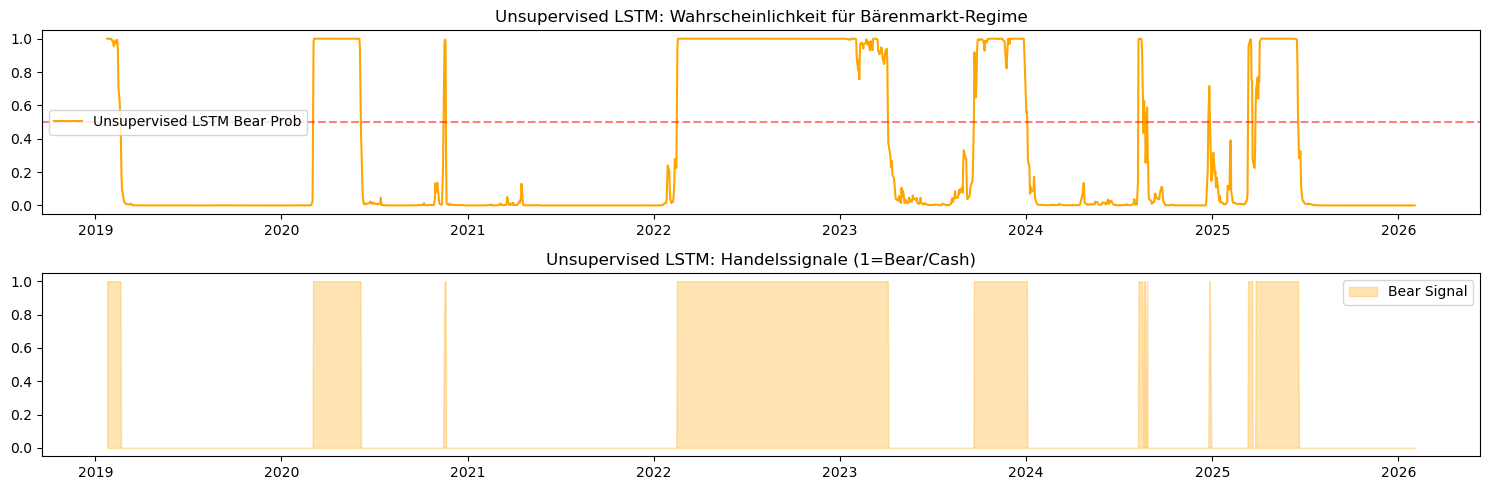

In [5]:
# --- 4. Unsupervised LSTM-Netzwerk ---

from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from tensorflow.keras.models import Model
from tensorflow.keras.layers import LSTM, Dense, RepeatVector, TimeDistributed, Input

# 1. Datenvorbereitung mit StandardScaler
features = ['Returns', 'Vol_20', 'Distance_SMA', 'Momentum', 'VIX', 'Yield_Spread']
scaler_unsup = StandardScaler()
scaled_data_unsup = scaler_unsup.fit_transform(df[features])

def create_sequences(data, window):
    X = []
    for i in range(window, len(data)):
        X.append(data[i-window:i])
    return np.array(X)

window_size = 30
X_all_unsup = create_sequences(scaled_data_unsup, window_size)

# Zeitreihen-Split (80/20) konsistent halten
split = int(len(X_all_unsup) * 0.8)
X_train_u = X_all_unsup[:split]
X_test_u = X_all_unsup[split:]

# 2. LSTM-Autoencoder Architektur
n_features = len(features)
inputs = Input(shape=(window_size, n_features))

encoder = LSTM(8, activation='tanh', return_sequences=False)(inputs) 

# Decoder
decoder = RepeatVector(window_size)(encoder)
decoder = LSTM(8, activation='tanh', return_sequences=True)(decoder)
output = TimeDistributed(Dense(n_features))(decoder)

autoencoder = Model(inputs, output)
autoencoder.compile(optimizer='adam', loss='mse')

print("Starte Training des Unsupervised LSTM-Autoencoders...")
# Training auf sich selbst (X -> X)
autoencoder.fit(X_train_u, X_train_u, epochs=50, batch_size=64, validation_split=0.1, verbose=0)

# 3. Latente Merkmale extrahieren (Der "Marktstimmungs-Vektor")
encoder_model = Model(inputs, encoder)
latent_features_test = encoder_model.predict(X_test_u)

# 4. Clustering mit GMM (Gaussian Mixture Model)
gmm = GaussianMixture(n_components=2, n_init=10, random_state=42)
gmm.fit(latent_features_test)

# Vorhersagen für das Test-Set
clusters = gmm.predict(latent_features_test)
probs = gmm.predict_proba(latent_features_test)

# 5. Automatisierte Zuordnung: Welches Cluster ist der Bärenmarkt?
# Wir verknüpfen die Cluster mit den echten Renditen im Test-Zeitraum
temp_results = pd.DataFrame({
    'Returns': df['Returns'].iloc[split + window_size:],
    'Cluster': clusters
})

# Wir berechnen die Standardabweichung (Vola) der Renditen pro Cluster
# Das Cluster mit der höheren Vola definieren wir als Bear (1)
bear_cluster = temp_results.groupby('Cluster')['Returns'].std().idxmax()
print(f"Bear-Regime identifiziert als Cluster: {bear_cluster}")

# 6. Ergebnisse im test_df speichern
# Wahrscheinlichkeit für Bärenmarkt
test_df['LSTM_Unsupervised_Prob'] = probs[:, bear_cluster]
# Binäres Signal (1 = Bear, 0 = Bull)
test_df['LSTM_Unsupervised_Signal'] = (clusters == bear_cluster).astype(int)

print("Unsupervised LSTM abgeschlossen und Signale gespeichert.")

# 7. Visualisierung der Ergebnisse
plt.figure(figsize=(15, 5))

# Plot der Wahrscheinlichkeit
plt.subplot(2, 1, 1)
plt.plot(test_df.index, test_df['LSTM_Unsupervised_Prob'], color='orange', label='Unsupervised LSTM Bear Prob')
plt.axhline(y=0.5, color='red', linestyle='--', alpha=0.5)
plt.title("Unsupervised LSTM: Wahrscheinlichkeit für Bärenmarkt-Regime")
plt.legend()

# Plot der Signale
plt.subplot(2, 1, 2)
plt.fill_between(test_df.index, 0, test_df['LSTM_Unsupervised_Signal'], color='orange', alpha=0.3, label='Bear Signal')
plt.title("Unsupervised LSTM: Handelssignale (1=Bear/Cash)")
plt.legend()

plt.tight_layout()
# Grafik für den Report speichern
plt.savefig('../assets/lstm_unsupervised_model.png', dpi=300, bbox_inches='tight')
plt.show()

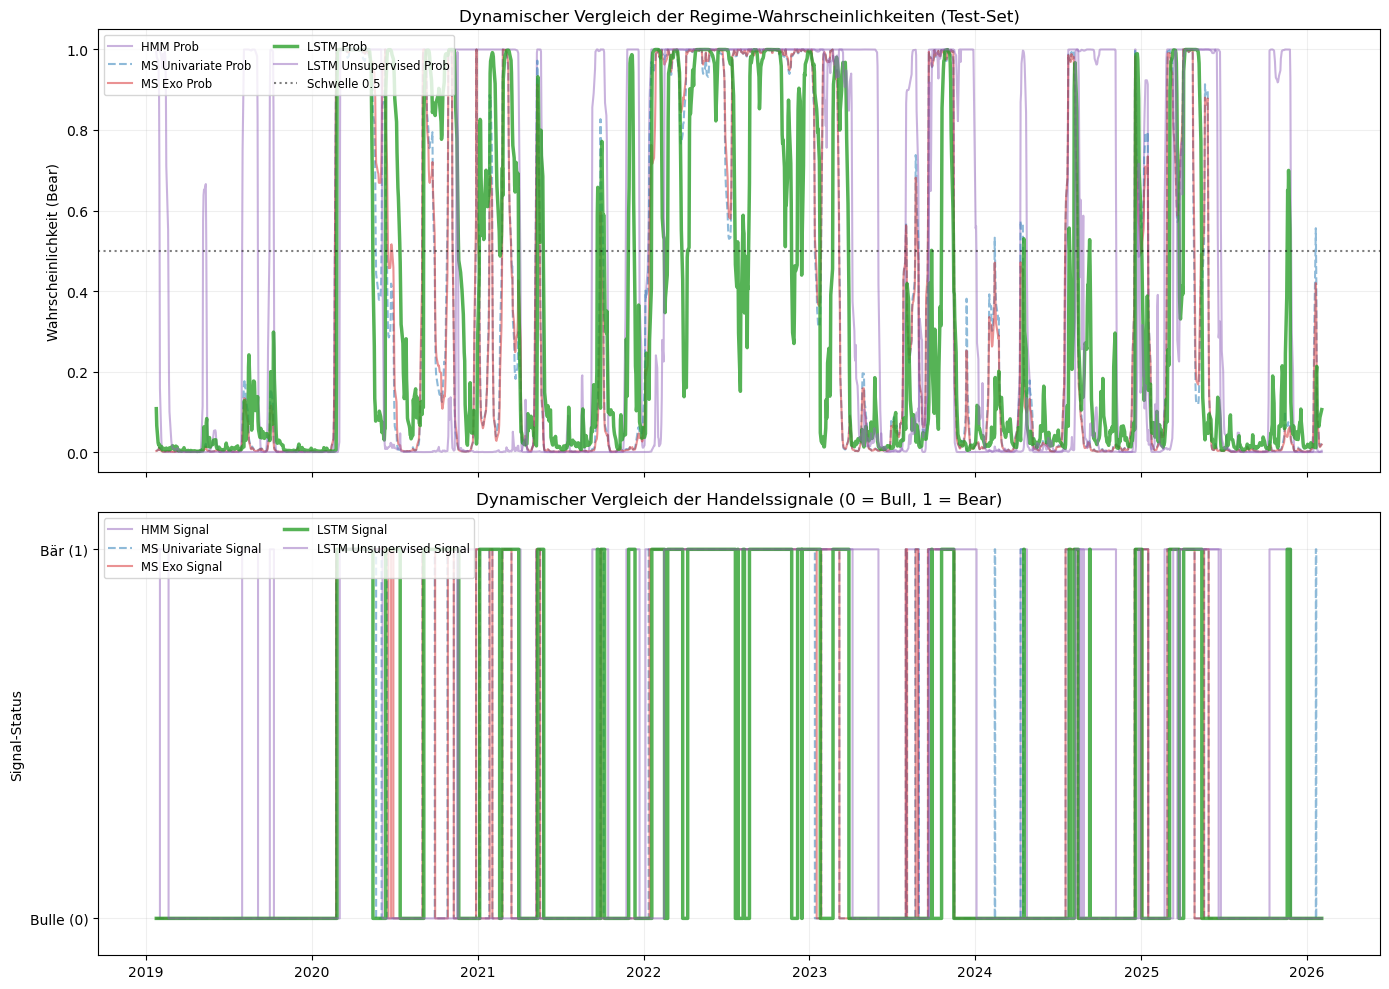

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Dynamische Identifikation der Modelle
# Wir suchen alle Spalten, die auf _Signal enden, um die Modellnamen zu extrahieren
model_names = [col.rsplit('_', 1)[0] for col in test_df.columns if col.endswith('_Signal')]

# 2. Farbschema definieren (optional, um Konsistenz zu wahren)
color_map = {
    'MS_Univariate': 'tab:blue',
    'MS_Exo': 'tab:red',
    'HMM': 'tab:purple',
    'LSTM': 'tab:green'
}
# Fallback für neue Modelle, die noch nicht in der Map sind
default_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

# 3. Plot erstellen
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

for i, model in enumerate(model_names):
    # Farbe bestimmen
    color = color_map.get(model, default_colors[i % len(default_colors)])
    
    # Linienstil-Logik (z.B. Univariat gestrichelt, Rest durchgezogen)
    ls = '--' if 'Univariate' in model else '-'
    lw = 2.5 if model == 'LSTM' else 1.5
    alpha = 0.8 if model == 'LSTM' else 0.5
    
    # --- Plot 1: Wahrscheinlichkeiten ---
    prob_col = f"{model}_Prob"
    if prob_col in test_df.columns:
        ax1.plot(test_df.index, test_df[prob_col], 
                 label=f"{model.replace('_', ' ')} Prob", 
                 color=color, linestyle=ls, alpha=alpha, linewidth=lw)

    # --- Plot 2: Signale ---
    sig_col = f"{model}_Signal"
    ax2.step(test_df.index, test_df[sig_col], 
             where='post', label=f"{model.replace('_', ' ')} Signal", 
             color=color, linestyle=ls, alpha=alpha, linewidth=lw)

# --- Ax1 Styling ---
ax1.axhline(y=0.5, color='black', linestyle=':', alpha=0.5, label='Schwelle 0.5')
ax1.set_title("Dynamischer Vergleich der Regime-Wahrscheinlichkeiten (Test-Set)")
ax1.set_ylabel("Wahrscheinlichkeit (Bear)")
ax1.legend(loc='upper left', fontsize='small', ncol=2)
ax1.grid(alpha=0.2)
ax1.set_ylim(-0.05, 1.05)

# --- Ax2 Styling ---
ax2.set_title("Dynamischer Vergleich der Handelssignale (0 = Bull, 1 = Bear)")
ax2.set_ylabel("Signal-Status")
ax2.set_yticks([0, 1])
ax2.set_yticklabels(['Bulle (0)', 'Bär (1)'])
ax2.legend(loc='upper left', fontsize='small', ncol=2)
ax2.grid(alpha=0.2)
ax2.set_ylim(-0.1, 1.1)

# Layout optimieren
plt.tight_layout()
# Regime Comparison persistieren
plt.savefig('../assets/regime_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

In [7]:
output_path = "../data/03_test_df_data.parquet"

# Speichern als Parquet
test_df.to_parquet(output_path)

print(f"Dataframe erfolgreich unter {output_path} gespeichert.")

Dataframe erfolgreich unter ../data/03_test_df_data.parquet gespeichert.
